In [1]:
from datasets import Dataset
from sklearn.model_selection import StratifiedKFold
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
import pandas as pd
import os

/home/sdonev/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from scipy.stats import sem
from sklearn.model_selection import train_test_split


# Prep Dataset

In [10]:
df_sentences = pd.read_csv("./sent_with_age_kw_new_split.csv")
df_sentences['doc_id_unique'] = df_sentences['doc_id'] + "_" + df_sentences['sentence_id'].astype(str).str.strip()
df_sentences

,Unnamed: 0,doc_id,sentence_id,tokens,ner_tags,sent_txt,entity_types,age,has_age_kw,doc_id_unique
0,15,My_pdf325new_method,15,"['Rats', 'in', 'the', 'AD', 'group', 'received...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...",Rats in the AD group received normal saline on...,[],0,True,My_pdf325new_method_15
1,27,My_pdf325new_method,27,"['The', 'rats', 'were', 'trained', 'two', 'tim...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...",The rats were trained two times a day for 5 da...,[],0,True,My_pdf325new_method_27
2,30,My_pdf325new_method,30,"['The', 'researches', 'were', 'performed', 'af...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...","The researches were performed after 7 , 14 , a...",[],0,True,My_pdf325new_method_30
3,32,My_pdf325new_method,32,"['The', 'following', 'experiments', 'were', 'p...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...",The following experiments were performed in AD...,[],0,True,My_pdf325new_method_32
4,103,My_pdf325new_method,103,"['The', '293', 'T', 'cell', 'lines', '(', 'pur...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...",The 293 T cell lines ( purchased from American...,[],0,True,My_pdf325new_method_103
...,...,...,...,...,...,...,...,...,...,...
3004,65949,My_pdf386new_method,35,"['Postoperative', 'management', 'of', 'ambulat...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...",Postoperative management of ambulatory patient...,[],0,True,My_pdf386new_method_35
3005,66002,My_pdf96new_method,22,"['A', 'β$_{25}$$_{-}$$_{35}$', 'peptide', 'was...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...",A β$_{25}$$_{-}$$_{35}$ peptide was dissolved ...,[],0,True,My_pdf96new_method_22
3006,66015,My_pdf96new_method,35,"['After', '7', 'days', 'of', 'habituation', ',...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...","After 7 days of habituation , mice were subjec...",[],0,True,My_pdf96new_method_35
3007,66016,My_pdf96new_method,36,"['24', 'h', 'later', ',', 'the', 'animals', 'r...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...","24 h later , the animals received orally eithe...",['therapy-drug'],0,True,My_pdf96new_method_36


In [11]:
df_sentences['age'].value_counts()


age
0    2561
1     448
Name: count, dtype: int64

In [12]:
# Stratified split: 80% train, 20% test
train_df, test_df = train_test_split(
    df_sentences,
    test_size=0.2,
    stratify=df_sentences["age"],
    random_state=42
)

# Save test set separately (optional but useful)
test_df.to_csv("./data/age_dataset_test.csv", index=False)
train_df.to_csv("./data/train_dataset_train_unbalanced.csv", index=False)

# Separate classes from training set only
df_majority = train_df[train_df['age'] == 0]
df_minority = train_df[train_df['age'] == 1]

# Downsample to 1.5× or 1.2× minority class
majority_target = int(1.5 * len(df_minority))  # or 1.2
df_majority_downsampled = df_majority.sample(n=majority_target, random_state=42)

# Combine and shuffle
df_balanced = pd.concat([df_majority_downsampled, df_minority], ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Save for training
df_balanced.to_csv("./data/age_dataset_balanced.csv", index=False)

In [8]:
df_balanced['age'].value_counts()

age
0    537
1    358
Name: count, dtype: int64

In [9]:
test_df['age'].value_counts()

age
0    512
1     90
Name: count, dtype: int64

In [52]:
test_df.shape

(602, 10)

In [10]:
df_balanced.shape

(895, 10)

# Evaluate models CV setup

In [11]:
os.environ["WANDB_PROJECT"] = "age-classification"
os.environ["WANDB_LOG_MODEL"] = "end"  # or "checkpoint"


In [ ]:
# --- Load dataset ---
#df = pd.read_csv("./data/age_dataset_balanced.csv")  # must have columns: sent_txt, age
df = df_sentences.copy()

print(f"Cross-validation for {df.shape} data size")

# --- Define models to evaluate ---
model_names = [
    "dmis-lab/biobert-base-cased-v1.1",
    "microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract",
    "michiyasunaga/BioLinkBERT-large",
    "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract",
    "michiyasunaga/BioLinkBERT-base",
    "allenai/scibert_scivocab_uncased"
]
# --- Metric function ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# --- Compute mean and 95% CI ---
def compute_mean_ci(series):
    mean = series.mean()
    se = sem(series)
    ci = 1.96 * se
    return pd.Series({
        "mean": round(mean, 4),
        "95% CI": f"[{round(mean - ci, 4)}, {round(mean + ci, 4)}]"
    })

# --- Loop through models ---
for model_name in model_names:
    print(f"\n🚀 Starting cross-validation for: {model_name}")
    all_metrics = []

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # 10-fold stratified CV
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    for fold, (train_idx, val_idx) in enumerate(skf.split(df["sent_txt"], df["age"])):
        print(f"\n🔁 Fold {fold + 1}")

        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df = df.iloc[val_idx].reset_index(drop=True)

        train_dataset = Dataset.from_pandas(train_df)
        val_dataset = Dataset.from_pandas(val_df)

        def tokenize_function(example):
            return tokenizer(example["sent_txt"], truncation=True, padding="max_length", max_length=128)

        train_dataset = train_dataset.map(tokenize_function, batched=True)
        val_dataset = val_dataset.map(tokenize_function, batched=True)

        train_dataset = train_dataset.rename_column("age", "labels")
        val_dataset = val_dataset.rename_column("age", "labels")

        train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
        val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
        output_dir =  f"/shares/animalwelfare.crs.uzh/age_sentence_classifiers_cv_output/unbalanced_train/{model_name.replace('/', '_')}_fold_{fold+1}"
        training_args = TrainingArguments(
            output_dir= output_dir,
            eval_strategy="epoch",
            save_strategy="epoch",  
            load_best_model_at_end=True,
            report_to="none",
            logging_dir=f"./logs/{model_name.replace('/', '_')}_fold_{fold+1}",
            logging_strategy="epoch",
            num_train_epochs=5,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=16,
            learning_rate=2e-5,
            weight_decay=0.01,
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            tokenizer=tokenizer,
            compute_metrics=compute_metrics,
        )

        trainer.train()
        metrics = trainer.evaluate()
        print(f"📊 Fold {fold + 1} metrics:", metrics)
        all_metrics.append(metrics)
        trainer.save_model(os.path.join(output_dir, "best"))

    # --- Summary: mean + 95% CI ---
    df_metrics = pd.DataFrame(all_metrics)
    summary_df = df_metrics.apply(compute_mean_ci)

    # Save to file
    model_name_str = model_name.replace("/", "_").replace("-", "_")
    save_dir = "./age_sentence_classifier/performances/unbalanced_train_set"
    os.makedirs(save_dir, exist_ok=True)
    summary_path = f"{save_dir}/{model_name_str}_cv_results.csv"
    summary_df.to_csv(summary_path)
    df_metrics.to_csv(f"{save_dir}/{model_name_str}_cv_results_all_folds.csv")
        
    print(f"\nSaved cross-validation results for {model_name} to {summary_path}")
    print(summary_df)

Cross-validation for (3009, 10) data size

🚀 Starting cross-validation for: dmis-lab/biobert-base-cased-v1.1

🔁 Fold 1


Map: 100%|██████████| 301/301 [00:00<00:00, 8474.71 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/sctmp/sdonev/ipykernel_4121399/2281832285.py:82: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.208100,0.160444,0.933555,0.800000,0.714286,0.909091
2,0.113900,0.181505,0.930233,0.803738,0.682540,0.977273
3,0.073200,0.193033,0.940199,0.812500,0.750000,0.886364
4,0.039100,0.240281,0.936877,0.795699,0.755102,0.840909
5,0.032500,0.250444,0.933555,0.791667,0.730769,0.863636


📊 Fold 1 metrics: {'eval_loss': 0.16044366359710693, 'eval_accuracy': 0.9335548172757475, 'eval_f1': 0.8, 'eval_precision': 0.7142857142857143, 'eval_recall': 0.9090909090909091, 'eval_runtime': 0.6845, 'eval_samples_per_second': 439.739, 'eval_steps_per_second': 27.758, 'epoch': 5.0}

🔁 Fold 2


Map: 100%|██████████| 301/301 [00:00<00:00, 7529.23 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/sctmp/sdonev/ipykernel_4121399/2281832285.py:82: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Map: 100%|██████████| 301/301 [00:00<00:00, 7621.50 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/sctmp/sdonev/ipykernel_4121399/2281832285.py:82: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.237200,0.179147,0.916944,0.782609,0.642857,1.000000
2,0.138000,0.148323,0.943522,0.824742,0.769231,0.888889
3,0.089600,0.184469,0.956811,0.863158,0.820000,0.911111
4,0.045200,0.227518,0.943522,0.824742,0.769231,0.888889
5,0.033100,0.240694,0.950166,0.842105,0.800000,0.888889


📊 Fold 5 metrics: {'eval_loss': 0.1483234167098999, 'eval_accuracy': 0.9435215946843853, 'eval_f1': 0.8247422680412372, 'eval_precision': 0.7692307692307693, 'eval_recall': 0.8888888888888888, 'eval_runtime': 0.6634, 'eval_samples_per_second': 453.698, 'eval_steps_per_second': 28.639, 'epoch': 5.0}

🔁 Fold 6


Map: 100%|██████████| 301/301 [00:00<00:00, 8475.16 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/sctmp/sdonev/ipykernel_4121399/2281832285.py:82: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.223600,0.163945,0.936877,0.786517,0.795455,0.777778
2,0.123300,0.214445,0.936877,0.753247,0.906250,0.644444
3,0.085600,0.192055,0.940199,0.808511,0.775510,0.844444


# Viz Performance

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import ast

def load_model_results_from_folder(folder_path, metric):
    """
    Load the specified metric and its CI from all _res.csv files in a folder.

    Returns:
    - results: List of dicts with 'value' and 'ci' for the metric
    - model_names: List of model names for labeling
    """
    results = []
    model_names = []

    for file in os.listdir(folder_path):
        if file.endswith("_results.csv"):
            model_name = file.replace("_cv_results.csv", "")
            file_path = os.path.join(folder_path, file)

            # Read with headers
            df = pd.read_csv(file_path)

            try:
                val = float(df[metric].iloc[0])
                ci = ast.literal_eval(df[metric].iloc[1])  # this should be a string like "[0.89, 0.94]"
            except KeyError:
                raise ValueError(f"Metric '{metric}' not found in {file}.")
            except Exception as e:
                raise ValueError(f"Error processing {file}: {e}")

            results.append({'value': val, 'ci': ci})
            model_names.append(model_name)

    return results, model_names


def plot_model_metric_with_ci_from_folder(
    folder_path,
    metric='eval_f1',
    annotation_type="test",
    save_dir="viz"
):
    """
    Load and plot a specified metric with its confidence interval from CSV files in a folder.
    Model names appear on Y-axis via horizontal bars.
    """
    results_list, model_names = load_model_results_from_folder(folder_path, metric)

    metric_vals = []
    ci_lows = []
    ci_highs = []

    for res in results_list:
        val = res['value']
        ci_low, ci_high = res['ci']
        metric_vals.append(val)
        ci_lows.append(val - ci_low)
        ci_highs.append(ci_high - val)

    y_pos = range(len(model_names))
    colors = plt.cm.Set2.colors[:len(model_names)]

    plt.figure(figsize=(10, 6))
    for i, (y, x, low, high, color) in enumerate(zip(y_pos, metric_vals, ci_lows, ci_highs, colors)):
        plt.errorbar(
            x=x,
            y=y,
            xerr=[[low], [high]],
            fmt='o',
            capsize=6,
            markersize=8,
            color=color,
            ecolor='gray',
            elinewidth=2,
            markerfacecolor=color
        )
        plt.text(
            x + 0.02, y, f"{x:.2f}",
            va='center',
            fontsize=11,
            color=color,
            weight='bold'
        )

    plt.yticks(ticks=y_pos, labels=model_names, fontsize=12)
    plt.xticks(fontsize=12)
    plt.xlabel(metric.replace("eval_", "").replace("_", " ").title(), fontsize=13)
    plt.ylabel("Model", fontsize=13)
    plt.title(f"{metric.replace('eval_', '').replace('_', ' ').title()} with 95% CI ({annotation_type})", fontsize=15)
    plt.xlim(0, 1.05)
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    os.makedirs(save_dir, exist_ok=True)
    filename = f"{metric}_horizontal_with_ci_{annotation_type}.png"
    plt.tight_layout()
    print(f"Saving to {os.path.join(save_dir, filename)}")
    plt.savefig(os.path.join(save_dir, filename))
    plt.show()


Saving to viz/eval_recall_horizontal_with_ci_test.png


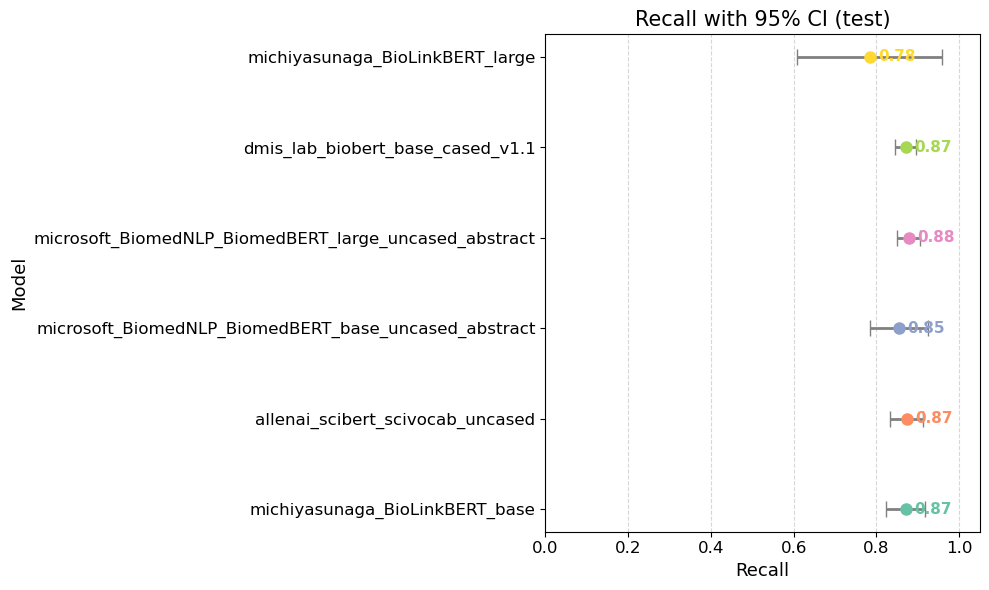

In [6]:
plot_model_metric_with_ci_from_folder(
    folder_path="./age_sentence_classifier/performances/unbalanced_train_set",
    metric="eval_recall",  # or eval_accuracy, eval_f1, etc.
    annotation_type="test"
)

Saving to viz/eval_f1_horizontal_with_ci_test.png


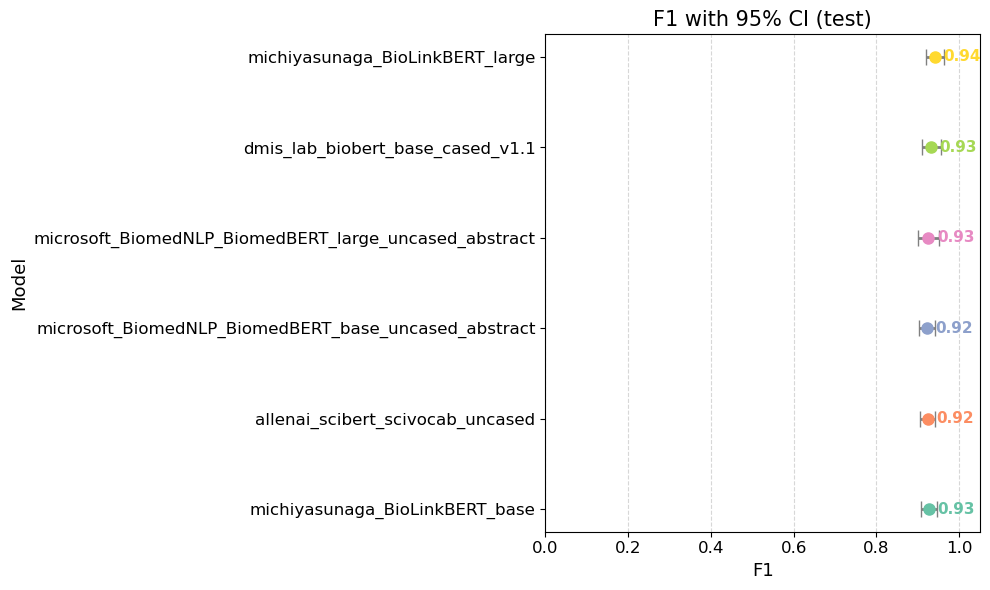

In [2]:
plot_model_metric_with_ci_from_folder(
    folder_path="./age_sentence_classifier/performances",
    metric="eval_f1",  # or eval_accuracy, eval_f1, etc.
    annotation_type="test"
)

Saving to viz/eval_recall_horizontal_with_ci_test.png


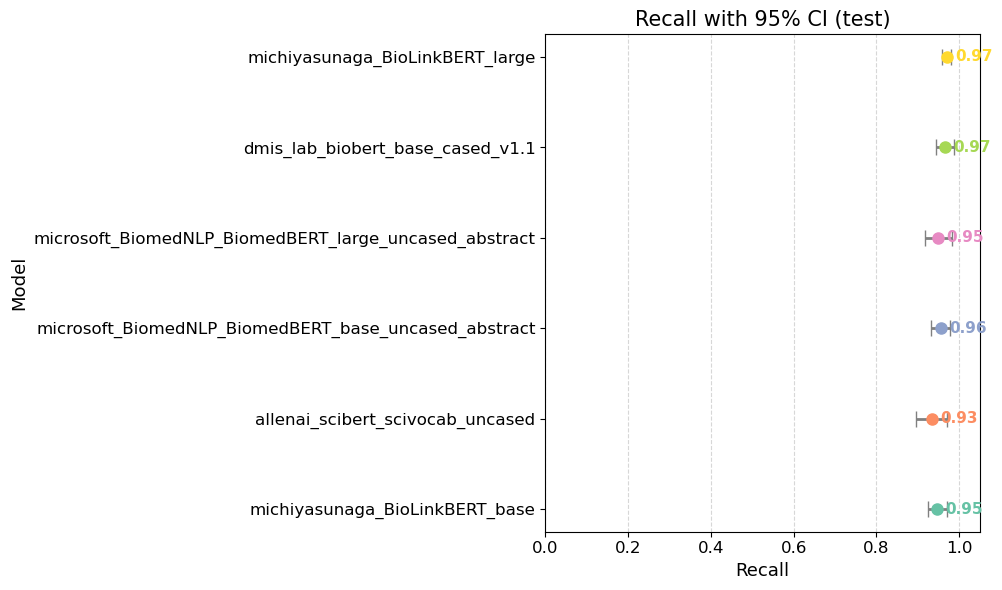

In [27]:
plot_model_metric_with_ci_from_folder(
    folder_path="./age_sentence_classifier/performances",
    metric="eval_recall",  # or eval_accuracy, eval_f1, etc.
    annotation_type="test"
)

Saving to viz/eval_precision_horizontal_with_ci_test.png


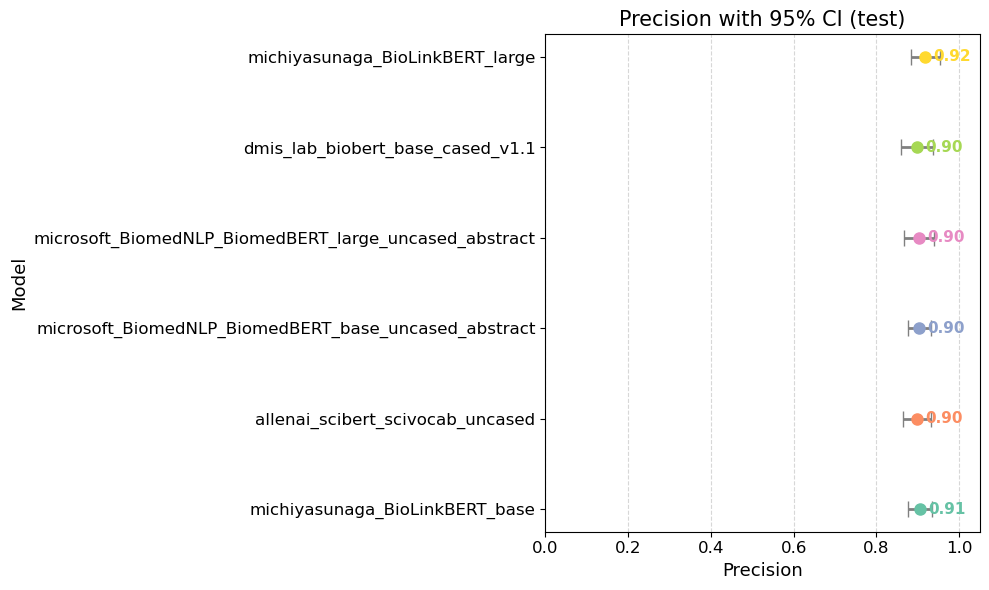

In [7]:
plot_model_metric_with_ci_from_folder(
    folder_path="./age_sentence_classifier/performances",
    metric="eval_precision",  # or eval_accuracy, eval_f1, etc.
    annotation_type="test"
)

# Test on Unbiased Test Set

In [10]:
df_test = pd.read_csv("./data/age_dataset_test.csv")
df_test.shape

(602, 10)

In [20]:
# === Metric computation ===
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}



def prepare_test_dataset(df, tokenizer):
    test_dataset = Dataset.from_pandas(df)
    test_dataset = test_dataset.map(lambda x: tokenizer(x["sent_txt"], truncation=True, padding="max_length", max_length=128), batched=True)
    test_dataset = test_dataset.rename_column("age", "labels")
    test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    return test_dataset

# === Summary statistics ===
def compute_mean_ci(series):
    mean = series.mean()
    se = sem(series)
    ci = 1.96 * se
    return pd.Series({
        "mean": round(mean, 4),
        "95% CI": f"[{round(mean - ci, 4)}, {round(mean + ci, 4)}]"
    })


In [8]:
from transformers import AutoModelForSequenceClassification, Trainer
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import os

# === Your models ===
model_names = [
    "dmis-lab/biobert-base-cased-v1.1",
    "microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract",
    "michiyasunaga/BioLinkBERT-large",
    "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract",
    "michiyasunaga/BioLinkBERT-base",
    "allenai/scibert_scivocab_uncased"
]


# === Test data loading and tokenization ===
df_test = pd.read_csv("./data/age_dataset_test.csv")

# === Output dir ===
os.makedirs("./age_sentence_classifier/performances/unbalanced_test_set", exist_ok=True)

# === Loop through all models ===
for model_name in model_names:
    print(f"\n🔍 Evaluating model: {model_name}")
    model_name_str = model_name.replace("/", "_")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    test_dataset = prepare_test_dataset(df_test, tokenizer)

    results = []

    for fold in range(1, 11):
        print(f"\n🧪 Fold {fold}")
        output_dir = f"/shares/animalwelfare.crs.uzh/age_sentence_classifiers_cv_output/{model_name_str}_fold_{fold}/best"
        
        try:
            model = AutoModelForSequenceClassification.from_pretrained(output_dir)
        except Exception as e:
            print(f"❌ Failed to load model for fold {fold}: {e}")
            continue

        trainer = Trainer(
            model=model,
            tokenizer=tokenizer,
            compute_metrics=compute_metrics
        )

        metrics = trainer.evaluate(eval_dataset=test_dataset)
        print(f"📊 Fold {fold} test metrics:", metrics)
        results.append(metrics)

    if results:
        df_results = pd.DataFrame(results)
        summary_df = df_results.apply(compute_mean_ci)
        print(f"\n📈 Final summary for {model_name}:")
        print(summary_df)

        # Save results
        summary_path = f"./age_sentence_classifier/performances/unbalanced_test_set/{model_name_str}_cv_results.csv"
        summary_df.to_csv(summary_path)
        print(f"✅ Saved summary to {summary_path}")
    else:
        print(f"⚠️ No valid results for {model_name}")


🔍 Evaluating model: dmis-lab/biobert-base-cased-v1.1


Map: 100%|██████████| 602/602 [00:00<00:00, 8523.86 examples/s]



🧪 Fold 1


/sctmp/sdonev/ipykernel_1636007/723673980.py:66: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


📊 Fold 1 test metrics: {'eval_loss': 0.2538142502307892, 'eval_model_preparation_time': 0.0029, 'eval_accuracy': 0.9169435215946844, 'eval_f1': 0.7727272727272727, 'eval_precision': 0.6538461538461539, 'eval_recall': 0.9444444444444444, 'eval_runtime': 1.5409, 'eval_samples_per_second': 390.673, 'eval_steps_per_second': 49.321}

🧪 Fold 2


...

📊 Fold 8 test metrics: {'eval_loss': 0.34625717997550964, 'eval_model_preparation_time': 0.0029, 'eval_accuracy': 0.8820598006644518, 'eval_f1': 0.7125506072874493, 'eval_precision': 0.5605095541401274, 'eval_recall': 0.9777777777777777, 'eval_runtime': 1.5045, 'eval_samples_per_second': 400.145, 'eval_steps_per_second': 50.517}

🧪 Fold 9


/sctmp/sdonev/ipykernel_1636007/723673980.py:66: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


📊 Fold 9 test metrics: {'eval_loss': 0.3060949146747589, 'eval_model_preparation_time': 0.0028, 'eval_accuracy': 0.9069767441860465, 'eval_f1': 0.75, 'eval_precision': 0.6268656716417911, 'eval_recall': 0.9333333333333333, 'eval_runtime': 1.518, 'eval_samples_per_second': 396.586, 'eval_steps_per_second': 50.067}

🧪 Fold 10


/sctmp/sdonev/ipykernel_1636007/723673980.py:66: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


📊 Fold 10 test metrics: {'eval_loss': 0.24552519619464874, 'eval_model_preparation_time': 0.0029, 'eval_accuracy': 0.8970099667774086, 'eval_f1': 0.7350427350427351, 'eval_precision': 0.5972222222222222, 'eval_recall': 0.9555555555555556, 'eval_runtime': 1.4933, 'eval_samples_per_second': 403.145, 'eval_steps_per_second': 50.895}

📈 Final summary for allenai/scibert_scivocab_uncased:
               eval_loss eval_model_preparation_time     eval_accuracy  \
mean              0.2699                      0.0028            0.9058   
95% CI  [0.2421, 0.2977]            [0.0027, 0.0029]  [0.8945, 0.9171]   

                 eval_f1    eval_precision       eval_recall  \
mean              0.7511            0.6277            0.9411   
95% CI  [0.7316, 0.7706]  [0.5948, 0.6606]  [0.9227, 0.9595]   

            eval_runtime eval_samples_per_second eval_steps_per_second  
mean              1.5049                400.0548               50.5053  
95% CI  [1.4976, 1.5122]     [398.116, 401.9936]   

Saving to viz/eval_f1_horizontal_with_ci_test.png


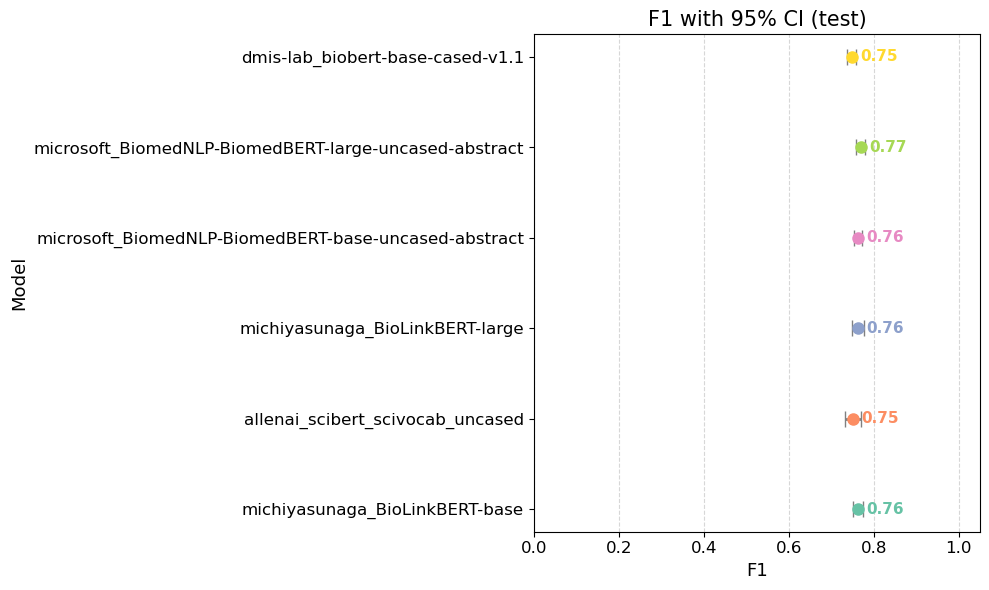

In [9]:
plot_model_metric_with_ci_from_folder(
    folder_path="./age_sentence_classifier/performances/unbalanced_test_set",
    metric="eval_f1",  # or eval_accuracy, eval_f1, etc.
    annotation_type="test"
)

Saving to viz/eval_precision_horizontal_with_ci_test.png


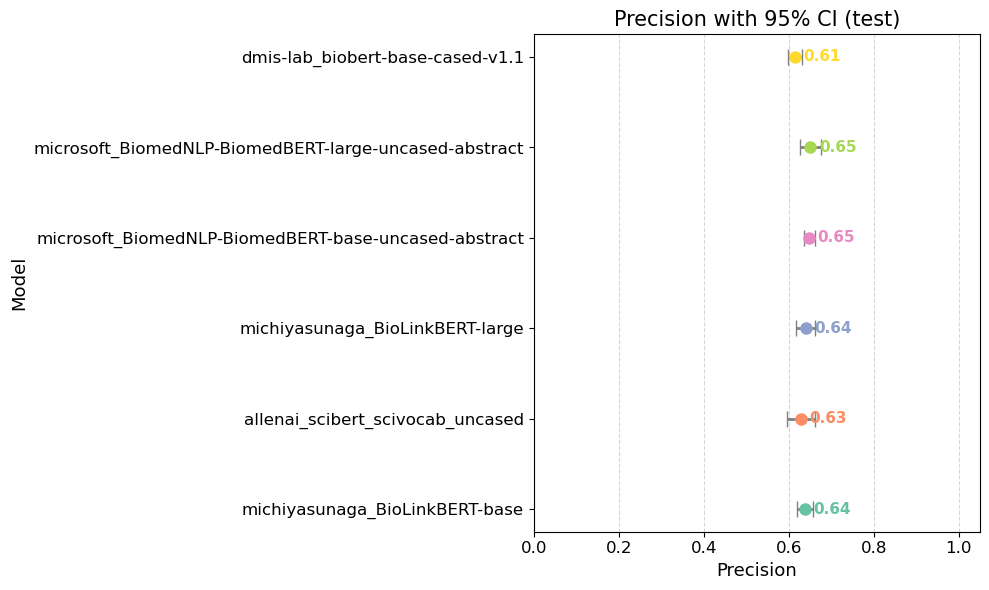

In [12]:
plot_model_metric_with_ci_from_folder(
    folder_path="./age_sentence_classifier/performances/unbalanced_test_set",
    metric="eval_precision",  # or eval_accuracy, eval_f1, etc.
    annotation_type="test"
)

# Final Model train

In [13]:
test_df = pd.read_csv("./data/age_dataset_test.csv")
train_df = pd.read_csv("./data/train_dataset_train_unbalanced.csv")
train_df_balanced = pd.read_csv("./data/age_dataset_balanced.csv")

train_df_balanced.shape, train_df.shape, test_df.shape

((895, 10), (2407, 10), (602, 10))

In [14]:
# 1. Check for duplicates within each set
print("\n🔎 Checking for duplicates within training and test sets...")
train_duplicates = train_df.duplicated(subset="doc_id_unique").sum()
test_duplicates = test_df.duplicated(subset="doc_id_unique").sum()
print(f"Duplicates in train set: {train_duplicates}")
print(f"Duplicates in test set: {test_duplicates}")

# 2. Check for overlap between train and test
print("\n🔎 Checking for overlap between train and test sets...")
overlap_ids = set(train_df["doc_id_unique"]) & set(test_df["doc_id_unique"])
print(f"Overlapping doc_id_unique values: {len(overlap_ids)}")

# 3. Print dataset sizes
print("\n📏 Dataset sizes:")
print(f"Train set: {train_df.shape}")
print(f"Test set: {test_df.shape}")



🔎 Checking for duplicates within training and test sets...
Duplicates in train set: 0
Duplicates in test set: 0

🔎 Checking for overlap between train and test sets...
Overlapping doc_id_unique values: 0

📏 Dataset sizes:
Train set: (2407, 10)
Test set: (602, 10)


In [40]:
train_df_balanced.head()

,Unnamed: 0,doc_id,sentence_id,tokens,ner_tags,sent_txt,entity_types,age,has_age_kw,doc_id_unique
0,54500,My_pdf13new_method,3,"['Adult', 'female', 'Long', '-', 'Evans', 'rat...","['B-age|B-weight', 'I-age|I-weight', 'B-strain...",Adult female Long - Evans rats ( Harlan Spragu...,"['strain', 'age', 'weight']",1,True,My_pdf13new_method_3
1,6435,My_pdf785_method,30,"['Tail', 'blood', '(', '1.5', 'ml', ')', 'was'...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...","Tail blood ( 1.5 ml ) was obtained at 0 , 2 an...",[],0,True,My_pdf785_method_30
2,51691,My_pdf494new_method,26,"['Therefore', ',', 'the', 'TD', 'animal', 'mod...","['O', 'O', 'O', 'B-disease', 'O', 'O', 'O', 'O...","Therefore , the TD animal model was establishe...",['disease'],0,True,My_pdf494new_method_26
3,53154,My_pdf936_method,7,"['Adult', 'mice', '(', '8', 'weeks', ')', 'wer...","['B-age', 'I-age', 'I-age', 'I-age', 'I-age', ...",Adult mice ( 8 weeks ) were anesthetized with ...,['age'],1,True,My_pdf936_method_7
4,32768,My_pdf18new_method,6,"['The', 'purified', 'cell', 'suspension', 'was...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...",The purified cell suspension was placed in a 2...,[],0,True,My_pdf18new_method_6


In [27]:
train_df_balanced['age'].value_counts()

age
0    537
1    358
Name: count, dtype: int64

In [15]:
train_df['age'].value_counts()

age
0    2049
1     358
Name: count, dtype: int64

In [28]:
test_df['age'].value_counts()

age
0    512
1     90
Name: count, dtype: int64

In [24]:
def tokenize_function(example):
    return tokenizer(example["sent_txt"], truncation=True, padding="max_length", max_length=128)

model_name = "microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model_name_str = model_name.replace("/", "_")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [25]:
train_dataset = Dataset.from_pandas(train_df)
train_dataset = train_dataset.map(tokenize_function, batched=True)
train_dataset = train_dataset.rename_column("age", "labels")
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])


Map: 100%|██████████| 2407/2407 [00:00<00:00, 9296.66 examples/s]


In [26]:
output_dir =  f"/shares/animalwelfare.crs.uzh/age_sentence_classifier_final/{model_name_str}"

# === 4. Define training arguments ===
training_args = TrainingArguments(
    output_dir=output_dir,
    eval_strategy="no",
    save_strategy="epoch",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="./logs/final_model_biomedbert",
    report_to="none"
)

# === 5. Trainer and training ===
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    tokenizer=tokenizer
)

trainer.train()
trainer.save_model(f"/shares/animalwelfare.crs.uzh/age_sentence_classifier_final/{model_name_str}/best")

/sctmp/sdonev/ipykernel_4168523/862715956.py:17: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.126500


In [28]:
test_dataset = Dataset.from_pandas(test_df)
test_dataset = test_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.rename_column("age", "labels")
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Reload the best model
model = AutoModelForSequenceClassification.from_pretrained(f"/shares/animalwelfare.crs.uzh/age_sentence_classifier_final/{model_name_str}/best")

trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

metrics = trainer.evaluate(eval_dataset=test_dataset)
print("📊 Final test set metrics:", metrics)

Map: 100%|██████████| 602/602 [00:00<00:00, 9107.49 examples/s]
/sctmp/sdonev/ipykernel_4168523/3586529696.py:9: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


📊 Final test set metrics: {'eval_loss': 0.2943907082080841, 'eval_model_preparation_time': 0.0092, 'eval_accuracy': 0.9435215946843853, 'eval_f1': 0.8191489361702127, 'eval_precision': 0.7857142857142857, 'eval_recall': 0.8555555555555555, 'eval_runtime': 4.7454, 'eval_samples_per_second': 126.859, 'eval_steps_per_second': 16.015}
